<h1 style="color:green;">📰 Fake News Detection</h1>

#### Objective:

The purpose of this project is to develop an end-to-end system that can automatically classify news articles 
as **Real** or **Fake** based on their text content using NLP techniques and machine learning models. 

---

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, joblib
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load Dataset
true = pd.read_csv("data/True.csv")
fake = pd.read_csv("data/Fake.csv")

true['label'] = 1  # 1 = Real
fake['label'] = 0  # 0 = Fake

df = pd.concat([true, fake]).sample(frac=1).reset_index(drop=True)

print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


✅ Dataset loaded successfully.
Shape: (44898, 5)


,title,text,subject,date,label
0,TUCKER CARLSON Calls Out Professor On His Clai...,"Another night, another idiot libtard who can t...",politics,"Dec 14, 2016",0
1,Swastika-Covered Guy Gets Punched In The Face...,One Nazi made the mistake of leaving his safe...,News,"October 20, 2017",0
2,"Danger of war, Germany warns after Trump's mov...",BERLIN (Reuters) - If the United States termin...,politicsNews,"October 14, 2017",1
3,Alabama’s Chief Justice Just Spit On The Cons...,One would think that to hold a position like C...,News,"January 6, 2016",0
4,"HOLY WIDOWS AND ORPHANS! Over 5,000 ISIS Train...",Europe s new new take on our Statue of Liberty...,politics,"Feb 21, 2016",0


label
0    23481
1    21417
Name: count, dtype: int64


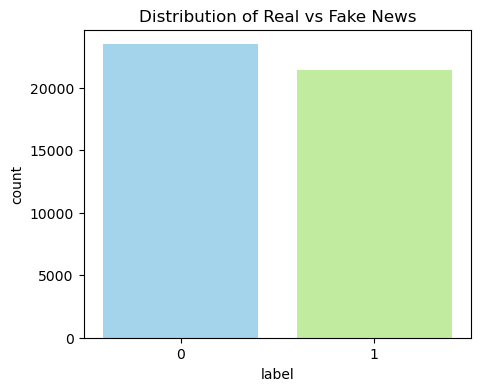

In [7]:
# Basic EDA
print(df['label'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df,palette=["#98d6f8", "#bff793"])
plt.title("Distribution of Real vs Fake News")
plt.show()

In [8]:
# Text Preprocessing

lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

def clean_text(text):
    """
    Clean text by removing punctuation, URLs, numbers, and stopwords.
    """
    text = re.sub(r'https?://\S+|www\.\S+', '', str(text))
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['text'] = (df['title'] + " " + df['text']).apply(clean_text)

print("✅ Text preprocessing completed.")
df.head()


✅ Text preprocessing completed.


,title,text,subject,date,label
0,TUCKER CARLSON Calls Out Professor On His Clai...,tucker carlson call professor claim russia sto...,politics,"Dec 14, 2016",0
1,Swastika-Covered Guy Gets Punched In The Face...,swastika covered guy get punched face outside ...,News,"October 20, 2017",0
2,"Danger of war, Germany warns after Trump's mov...",danger war germany warns trump move iran nucle...,politicsNews,"October 14, 2017",1
3,Alabama’s Chief Justice Just Spit On The Cons...,alabama chief justice spit constitution reinst...,News,"January 6, 2016",0
4,"HOLY WIDOWS AND ORPHANS! Over 5,000 ISIS Train...",holy widow orphan isi trained jihadi living fr...,politics,"Feb 21, 2016",0


In [9]:
#  Balance the Dataset (Oversampling)

from sklearn.utils import resample

df_real = df[df.label == 1]
df_fake = df[df.label == 0]

# Oversample the smaller class
if len(df_real) > len(df_fake):
    df_fake_over = resample(df_fake, replace=True, n_samples=len(df_real), random_state=42)
    df_balanced = pd.concat([df_real, df_fake_over])
else:
    df_real_over = resample(df_real, replace=True, n_samples=len(df_fake), random_state=42)
    df_balanced = pd.concat([df_real_over, df_fake])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Dataset balanced successfully:")
print(df_balanced['label'].value_counts())


✅ Dataset balanced successfully:
label
1    23481
0    23481
Name: count, dtype: int64


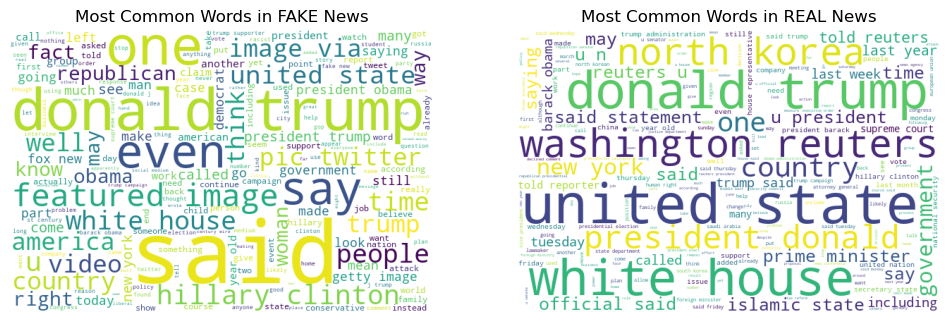

In [10]:
# Bonus: WordCloud Visualization
fake_text = " ".join(df_balanced[df_balanced['label']==0]['text'])
real_text = " ".join(df_balanced[df_balanced['label']==1]['text'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(fake_text))
plt.title("Most Common Words in FAKE News", fontsize=12)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(real_text))
plt.title("Most Common Words in REAL News", fontsize=12)
plt.axis('off')

plt.show()

In [11]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'], df_balanced['label'], test_size=0.2, random_state=42, stratify=df_balanced['label']
)

In [12]:
# Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("✅ TF-IDF vectorization done.")
print("Shape:", X_train_vec.shape)


✅ TF-IDF vectorization done.
Shape: (37569, 5000)


In [13]:
# Model Training & Comparison 

models = {
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    # AUC calculation (for models supporting decision_function or predict_proba)
    try:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_vec)[:, 1]
        else:
            y_prob = model.decision_function(X_test_vec)
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = None
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).set_index("Model").sort_values(by="F1-Score", ascending=False)

print("\n🔹 Model Performance Comparison:\n")
display(results_df.style.background_gradient(cmap="Greens").format("{:.4f}"))



🔹 Model Performance Comparison:



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9991,0.9994,0.9989,0.9991,1.0000
SVM (LinearSVC),0.9961,0.9957,0.9964,0.9961,0.9999
Logistic Regression,0.9894,0.9867,0.9921,0.9894,0.9993


In [14]:
# Best Model Selection

# Find the model with the highest F1-Score
best_model_name = results_df["F1-Score"].idxmax()
print(f"\n✅ Best model based on F1-Score: {best_model_name}")

# Retrieve the trained model from the models dictionary
best_model = models[best_model_name]



✅ Best model based on F1-Score: Random Forest


✅ Evaluation Metrics for Random Forest:
Accuracy : 0.9991
Precision: 0.9994
Recall   : 0.9989
F1-Score : 0.9991
ROC-AUC  : 1.0000


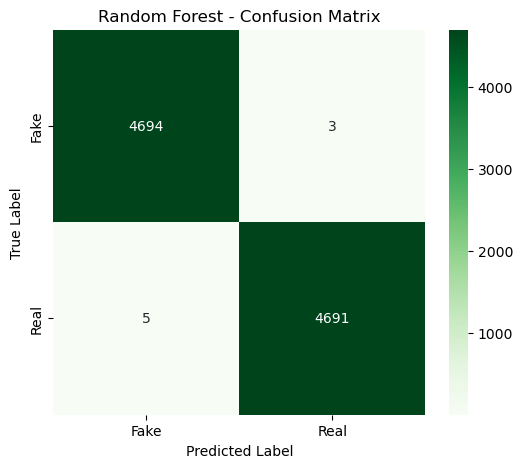

In [15]:
# Evaluation of Best Model

# Predictions
y_pred = best_model.predict(X_test_vec)

# Compute metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

# ROC-AUC (for models supporting decision_function or predict_proba)
try:
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test_vec)[:,1]
    else:
        y_prob = best_model.decision_function(X_test_vec)
    auc = roc_auc_score(y_test, y_prob)
except Exception:
    auc = None

# Print metrics
print(f"✅ Evaluation Metrics for {best_model_name}:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
if auc:
    print(f"ROC-AUC  : {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [16]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake','Real']))



Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4697
        Real       1.00      1.00      1.00      4696

    accuracy                           1.00      9393
   macro avg       1.00      1.00      1.00      9393
weighted avg       1.00      1.00      1.00      9393



In [17]:
# Save Best Model and Vectorizer
joblib.dump(best_model, "models/model.pkl")
joblib.dump(vectorizer, "models/vectorizer.pkl")

print("✅ Model and vectorizer saved successfully.")

✅ Model and vectorizer saved successfully.


---